  SECTION 1 – DATASET UNDERSTANDING

  SECTION 2 – DATA PREPROCESSING

✔  Dataset loaded successfully!
   Shape : 253680 rows  ×  22 columns

── First 3 rows ──
   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  HvyAlcoholConsump  AnyHealthcare  NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex  Age  Education  Income
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0                   0.0           0.0     0.0      1.0                0.0            1.0          0.0      5.0      18.0      15.0       1.0  0.0  9.0        4.0     3.0
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0                   0.0           1.0     0.0      0.0                0.0            0.0          1.0      3.0       0.0       0.0       0.0  0.0  7.0        6.0     1.0
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0                   0.0           0.0     1.0      0.0               

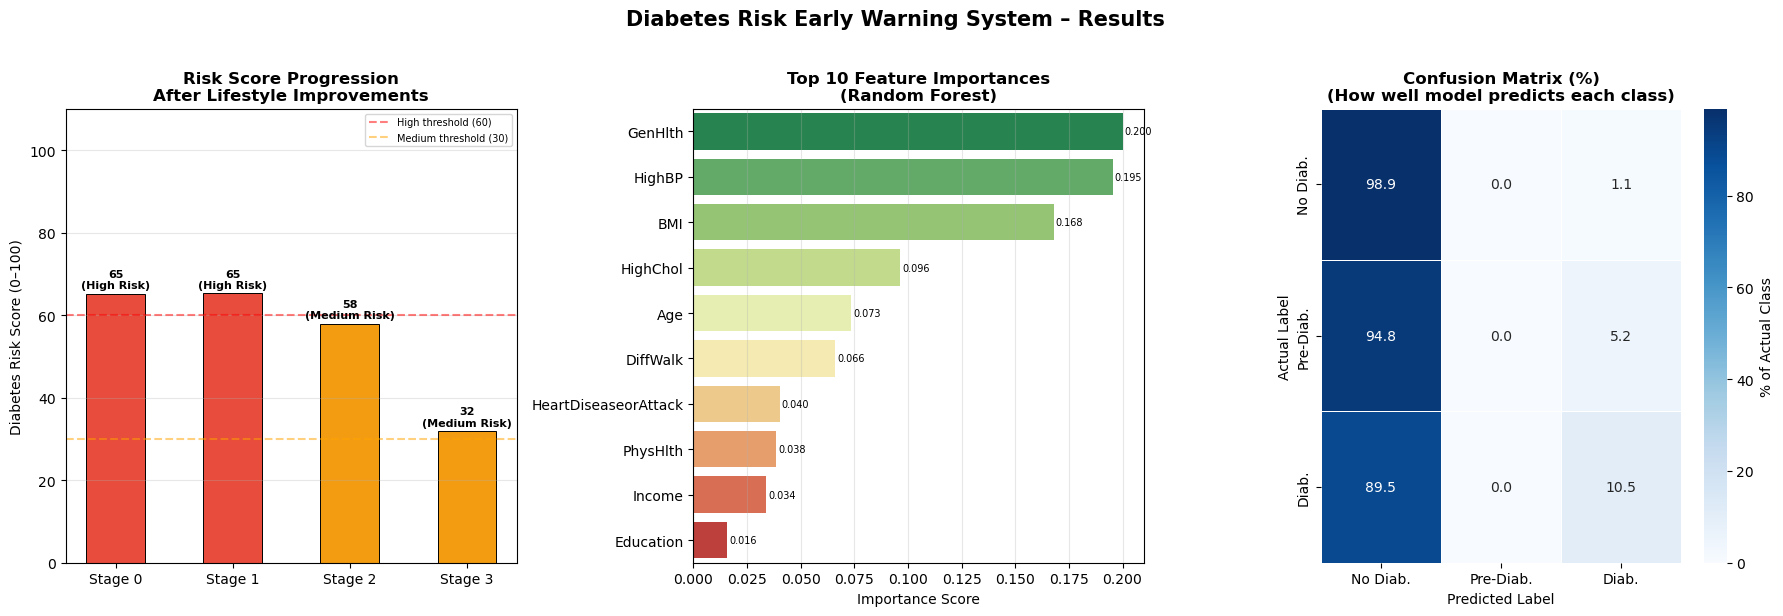


   ✔  All plots saved to 'diabetes_risk_results.png'

  SECTION 7 – PROJECT SUMMARY

  MODEL PERFORMANCE
  ─────────────────
  Algorithm  : Random Forest (100 trees, max depth 10)
  Accuracy   : 84.79%
  Evaluation : Confusion Matrix + Classification Report

  RISK SCORING FORMULA
  ────────────────────
  Risk Score = P(Pre-Diabetes) × 50  +  P(Diabetes) × 100
  Low Risk   : Score < 30
  Medium Risk: 30 ≤ Score < 60
  High Risk  : Score ≥ 60

  LIFESTYLE SIMULATION RESULT (sample patient)
  ─────────────────────────────────────────────
  Stage 0 → 65.2 (High Risk)
  Stage 1 → 65.2 (High Risk)
  Stage 2 → 57.9 (Medium Risk)
  Stage 3 → 31.9 (Medium Risk)
  Net Improvement : 33.3 risk points

  HOW THIS SUPPORTS EARLY WARNING & PREVENTION
  ─────────────────────────────────────────────
  1. Patient enters lifestyle data (BMI, activity level, etc.)
  2. System gives an immediate, understandable risk SCORE (not just class)
  3. System simulates "what if" scenarios → shows benefit of chang

  Do you have High Blood Pressure? (0=No / 1=Yes):  1
  Do you have High Cholesterol?    (0=No / 1=Yes):  2


   ⚠  Please enter a number between 0 and 1.


  Do you have High Cholesterol?    (0=No / 1=Yes):  1
  Had cholesterol check in past 5 yrs? (0=No / 1=Yes):  0
  Have you ever had a Stroke?       (0=No / 1=Yes):  1
  Heart disease or heart attack ever? (0=No / 1=Yes):  0



─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
  SECTION B – Body & Lifestyle
─────────────────────────────────────────────────────────────────
  BMI (Body Mass Index) guide:
    Underweight < 18.5 | Normal 18.5–24.9 | Overweight 25–29.9 | Obese ≥ 30


In [ ]:
"""
=============================================================================
  Lifestyle-Based Diabetes Risk Progression and Early Warning System
  Using Machine Learning
=============================================================================
  Dataset  : diabetes_012_health_indicators_BRFSS2015.csv
  Author   : B.Tech AIML Final Year Project
  Model    : Random Forest Classifier (no deep learning)
  Python   : 3.x
=============================================================================

HOW TO RUN:
    pip install pandas scikit-learn matplotlib seaborn
    python diabetes_risk_system.py

SECTION INDEX:
    1. Dataset Understanding
    2. Data Preprocessing
    3. Machine Learning Model
    4. Feature Importance
    5. Lifestyle-Based Risk Simulation
    6. Visualizations
=============================================================================
"""

# ─────────────────────────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 – DATASET UNDERSTANDING
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 65)
print("  SECTION 1 – DATASET UNDERSTANDING")
print("=" * 65)

"""
WHAT IS THIS DATASET?
─────────────────────
The BRFSS (Behavioral Risk Factor Surveillance System) 2015 dataset
was collected by the CDC (US Centers for Disease Control).
It contains survey responses from ~253,000 Americans about their
health conditions and lifestyle habits.

TARGET VARIABLE: Diabetes_012
  0 → No diabetes (healthy)
  1 → Pre-diabetes (blood sugar higher than normal, but not yet diabetic)
  2 → Diabetes (diagnosed diabetic)

LIFESTYLE FEATURES (why they matter):
  BMI            – Body Mass Index; obesity is a major diabetes risk factor
  PhysActivity   – Physical activity burns sugar; inactivity increases risk
  GenHlth        – Self-rated general health (1=Excellent … 5=Poor)
  Fruits         – Daily fruit consumption; better diet → lower risk
  Veggies        – Daily vegetable consumption
  Smoker         – Smoking worsens insulin resistance
  HvyAlcoholConsump – Heavy alcohol affects blood sugar control
  MentHlth       – Poor mental health → poor lifestyle habits
  PhysHlth       – Physical illness days; chronic illness linked to diabetes
  DiffWalk       – Difficulty walking; sign of physical deterioration

FEATURES SUITABLE FOR LIFESTYLE SIMULATION (can be changed by the person):
  BMI, PhysActivity, GenHlth, Fruits, Veggies, Smoker, HvyAlcoholConsump
"""

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 – DATA PREPROCESSING
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SECTION 2 – DATA PREPROCESSING")
print("=" * 65)

# ── 2.1  Load the dataset ──────────────────────────────────────────────────
# Update this path if your CSV is in a different folder
DATA_PATH = "diabetes_012_health_indicators_BRFSS2015.csv"

df = pd.read_csv(DATA_PATH)
print(f"\n✔  Dataset loaded successfully!")
print(f"   Shape : {df.shape[0]} rows  ×  {df.shape[1]} columns")

# ── 2.2  Inspect the data ──────────────────────────────────────────────────
print("\n── First 3 rows ──")
print(df.head(3).to_string())

print("\n── Data types ──")
print(df.dtypes)

# ── 2.3  Check for missing values ─────────────────────────────────────────
missing = df.isnull().sum()
print(f"\n── Missing values ──")
if missing.sum() == 0:
    print("   ✔  No missing values found. Dataset is clean!")
else:
    print(missing[missing > 0])
    # Fill numeric columns with their median (robust to outliers)
    df.fillna(df.median(), inplace=True)
    print("   ✔  Missing values filled with column medians.")

# ── 2.4  Target distribution ──────────────────────────────────────────────
print("\n── Target variable distribution ──")
counts = df["Diabetes_012"].value_counts().sort_index()
labels = {0: "No Diabetes", 1: "Pre-Diabetes", 2: "Diabetes"}
for k, v in counts.items():
    pct = v / len(df) * 100
    print(f"   Class {int(k)} ({labels[k]}): {v:,}  ({pct:.1f}%)")

# ── 2.5  Separate features (X) and target (y) ─────────────────────────────
X = df.drop(columns=["Diabetes_012"])   # All columns except the label
y = df["Diabetes_012"]                  # The label column

FEATURE_NAMES = X.columns.tolist()
print(f"\n   Features used : {len(FEATURE_NAMES)}")

# ── 2.6  Train / Test split ───────────────────────────────────────────────
# 80% for training, 20% for testing; random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\n   Train size : {len(X_train):,} rows")
print(f"   Test  size : {len(X_test):,} rows")

# ── 2.7  Feature scaling ──────────────────────────────────────────────────
# StandardScaler → mean=0, std=1
# Random Forest doesn't strictly need scaling, but it helps if you switch to
# Logistic Regression later – we keep it for generality.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit on train, then transform
X_test_scaled  = scaler.transform(X_test)         # Only transform (no re-fit)
print("\n   ✔  Features scaled with StandardScaler.")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 – MACHINE LEARNING MODEL
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SECTION 3 – MACHINE LEARNING MODEL")
print("=" * 65)

# ── 3.1  Train Random Forest ──────────────────────────────────────────────
"""
WHY RANDOM FOREST?
  • Handles mixed data (binary + continuous columns) very well
  • Gives feature importances automatically
  • Robust to outliers
  • No deep learning required
  • Provides predict_proba() → we get a probability, not just a class
"""
print("\n   Training Random Forest …  (this may take ~30 seconds)")

rf_model = RandomForestClassifier(
    n_estimators=100,   # 100 decision trees
    max_depth=10,       # Limit depth to avoid overfitting
    random_state=42,
    n_jobs=-1           # Use all CPU cores for speed
)
rf_model.fit(X_train_scaled, y_train)
print("   ✔  Training complete!")

# ── 3.2  Predict on test set ──────────────────────────────────────────────
y_pred       = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)  # Shape: (n_samples, 3)

# ── 3.3  Evaluate the model ───────────────────────────────────────────────
acc = accuracy_score(y_test, y_pred)
print(f"\n   Model Accuracy : {acc * 100:.2f}%")

print("\n── Classification Report ──")
print(classification_report(y_test, y_pred,
                             target_names=["No Diabetes","Pre-Diabetes","Diabetes"]))

print("── Confusion Matrix ──")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print("  Rows = Actual class,  Columns = Predicted class")


# ── 3.4  Convert probability to Risk Score (0–100) ────────────────────────
"""
HOW DO WE GET A CONTINUOUS RISK SCORE?
  The model gives 3 probabilities for each person:
    P(No Diabetes), P(Pre-Diabetes), P(Diabetes)

  We define:
    Risk Score = P(Pre-Diabetes) × 50  +  P(Diabetes) × 100
  This gives:
    - A person fully healthy        → score near   0
    - A person fully pre-diabetic   → score near  50
    - A person fully diabetic       → score near 100
"""

def compute_risk_score(proba_row):
    """
    proba_row : array of 3 probabilities [P_0, P_1, P_2]
    Returns   : float risk score in [0, 100]
    """
    p_healthy    = proba_row[0]   # probability of no diabetes
    p_prediab    = proba_row[1]   # probability of pre-diabetes
    p_diab       = proba_row[2]   # probability of diabetes
    score = p_prediab * 50 + p_diab * 100
    return round(score, 2)

# Apply to entire test set
risk_scores = np.array([compute_risk_score(row) for row in y_pred_proba])


# ── 3.5  Categorise risk score ────────────────────────────────────────────
def categorise_risk(score):
    """
    Low    : score < 30   → lifestyle is generally healthy
    Medium : 30 ≤ score < 60 → some risk factors present
    High   : score ≥ 60   → significant risk, needs attention
    """
    if score < 30:
        return "Low Risk"
    elif score < 60:
        return "Medium Risk"
    else:
        return "High Risk"

risk_categories = [categorise_risk(s) for s in risk_scores]

# Summary
unique, counts_cat = np.unique(risk_categories, return_counts=True)
print("\n── Risk Score Distribution ──")
for cat, cnt in zip(unique, counts_cat):
    print(f"   {cat:<15}: {cnt:,} people")

# Sample output for first 5 test cases
print("\n── Sample Risk Scores (first 5 test cases) ──")
print(f"  {'Actual':<14} {'Predicted':<14} {'Risk Score':<12} {'Category'}")
print("  " + "-" * 56)
for i in range(5):
    actual   = labels[y_test.iloc[i]]
    pred_lbl = labels[y_pred[i]]
    rs       = risk_scores[i]
    cat      = risk_categories[i]
    print(f"  {actual:<14} {pred_lbl:<14} {rs:<12.1f} {cat}")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 – FEATURE IMPORTANCE & EXPLANATION
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SECTION 4 – FEATURE IMPORTANCE")
print("=" * 65)

importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({
    "Feature"   : FEATURE_NAMES,
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("\n── Top 10 Features Contributing to Diabetes Risk ──")
print(feat_imp_df.head(10).to_string(index=False))

print("""
── What does Feature Importance mean? ──
   A higher importance means that feature has a larger effect
   on the model's prediction. Think of it as "how much does
   this factor push someone toward or away from diabetes?"

── Medical Explanation of Top Features ──
  BMI            – Excess body fat → cells resist insulin → blood sugar rises
  GenHlth        – Poor overall health is both a cause and effect of diabetes
  Age            – Risk increases significantly after 45
  HighBP         – High blood pressure and diabetes often co-occur
  PhysHlth       – Chronic physical illness days signal metabolic problems
  PhysActivity   – Exercise improves insulin sensitivity directly
  Income         – Lower income limits access to healthy food and healthcare
  DiffWalk       – Mobility issues often indicate advanced metabolic disease
  HighChol       – High cholesterol is part of the metabolic syndrome
  MentHlth       – Stress hormones raise blood sugar levels
""")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 – LIFESTYLE-BASED RISK SIMULATION  (KEY PART)
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 65)
print("  SECTION 5 – LIFESTYLE-BASED RISK SIMULATION")
print("=" * 65)

"""
WHAT IS RISK SIMULATION?
  Instead of just predicting "you have diabetes", we ask:
  "If this person improves their lifestyle step by step,
   how does their risk score change?"

This is the core of an EARLY WARNING SYSTEM:
  → Show a high-risk person the impact of small changes
  → Motivate gradual improvement
  → Demonstrate: High Risk → Medium Risk → Low Risk
"""

# ── 5.1  Pick a high-risk person from the test set ──────────────────────
# Find an actual diabetic (class 2) for a dramatic simulation
high_risk_indices = np.where((y_test.values == 2) & (risk_scores >= 60))[0]

if len(high_risk_indices) == 0:
    # fallback: just pick highest risk score
    sample_idx = np.argmax(risk_scores)
else:
    sample_idx = high_risk_indices[0]

# Get that person's original features as a dict
original_features = X_test.iloc[sample_idx].to_dict()
original_score    = risk_scores[sample_idx]
original_category = categorise_risk(original_score)

print(f"\n   Selected patient index : {sample_idx}")
print(f"   Original risk score    : {original_score:.1f}  →  {original_category}")
print("\n── Patient's Current Lifestyle Values ──")
lifestyle_cols = ["BMI","PhysActivity","GenHlth","Fruits","Veggies",
                  "Smoker","HvyAlcoholConsump","HighBP"]
for col in lifestyle_cols:
    print(f"   {col:<22}: {original_features[col]}")


# ── 5.2  Define lifestyle improvement steps ──────────────────────────────
"""
IMPROVEMENT PLAN (3 progressive stages):

Stage 1 – Small changes (easy to start):
  • Quit smoking
  • Reduce heavy alcohol
  • Add fruits/veggies

Stage 2 – Moderate effort:
  • Start physical activity
  • Improve general health rating (diet + sleep)
  • Slightly reduce BMI

Stage 3 – Significant effort:
  • Reduce BMI toward healthy range
  • Consistently maintain physical activity
  • Better overall health management
"""

def apply_improvements(features_dict, stage):
    """
    features_dict : dict of feature_name → value
    stage         : 0 (baseline), 1, 2, or 3
    Returns       : new dict with improved values
    """
    f = features_dict.copy()

    if stage >= 1:
        f["Smoker"]            = 0          # Quit smoking
        f["HvyAlcoholConsump"] = 0          # Stop heavy drinking
        f["Fruits"]            = 1          # Eat fruits daily
        f["Veggies"]           = 1          # Eat veggies daily

    if stage >= 2:
        f["PhysActivity"] = 1               # Start exercising
        f["GenHlth"]      = max(1, f["GenHlth"] - 1)   # Improve health score
        f["BMI"]          = max(18.5, f["BMI"] - 3)    # Lose some weight

    if stage >= 3:
        f["BMI"]      = max(18.5, f["BMI"] - 5)        # Lose more weight
        f["GenHlth"]  = max(1, f["GenHlth"] - 1)       # Further improvement
        f["HighBP"]   = max(0, f["HighBP"] - 1)        # BP control (medical)

    return f


def predict_risk_score(features_dict):
    """
    Given a feature dict, scale it and get risk score from the model.
    """
    row_df     = pd.DataFrame([features_dict])[FEATURE_NAMES]  # keep column order
    row_scaled = scaler.transform(row_df)
    proba      = rf_model.predict_proba(row_scaled)[0]
    return compute_risk_score(proba)


# ── 5.3  Run simulation ───────────────────────────────────────────────────
stage_labels = [
    "Stage 0 – Current Lifestyle",
    "Stage 1 – Quit smoking, eat better",
    "Stage 2 – Exercise + slight weight loss",
    "Stage 3 – Significant weight loss + BP control"
]

simulation_scores    = []
simulation_categories= []

for stage in range(4):
    improved_features = apply_improvements(original_features, stage)
    score = predict_risk_score(improved_features)
    cat   = categorise_risk(score)
    simulation_scores.append(score)
    simulation_categories.append(cat)

# ── 5.4  Print simulation results ────────────────────────────────────────
print("\n── Risk Progression After Lifestyle Improvements ──")
print(f"  {'Stage':<45} {'Risk Score':<12} {'Category'}")
print("  " + "-" * 70)
for i, (label, score, cat) in enumerate(
        zip(stage_labels, simulation_scores, simulation_categories)):
    marker = " ◄── START" if i == 0 else ""
    print(f"  {label:<45} {score:<12.1f} {cat}{marker}")

print(f"""
── What this simulation shows ──
   • Starting risk score : {simulation_scores[0]:.1f}  ({simulation_categories[0]})
   • Final risk score    : {simulation_scores[-1]:.1f}  ({simulation_categories[-1]})
   • Total risk reduction: {simulation_scores[0] - simulation_scores[-1]:.1f} points

   This demonstrates the EARLY WARNING concept:
   → The system doesn't just say "you have diabetes"
   → It says "if you make these changes, your risk drops THIS MUCH"
   → This motivates the person to act BEFORE diabetes develops
""")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6 – VISUALIZATIONS
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 65)
print("  SECTION 6 – VISUALIZATIONS")
print("=" * 65)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Diabetes Risk Early Warning System – Results", fontsize=15,
             fontweight="bold", y=1.02)

# ── Plot 1: Risk Score Before vs After Lifestyle Improvement ──────────────
ax1 = axes[0]
colors = ["#e74c3c" if c == "High Risk"
          else "#f39c12" if c == "Medium Risk"
          else "#27ae60"
          for c in simulation_categories]

bars = ax1.bar(
    [f"Stage {i}" for i in range(4)],
    simulation_scores,
    color=colors,
    edgecolor="black",
    linewidth=0.7,
    width=0.5
)

# Add value labels on bars
for bar, score, cat in zip(bars, simulation_scores, simulation_categories):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.8,
             f"{score:.0f}\n({cat})",
             ha="center", va="bottom", fontsize=8, fontweight="bold")

ax1.set_title("Risk Score Progression\nAfter Lifestyle Improvements",
              fontweight="bold")
ax1.set_ylabel("Diabetes Risk Score (0–100)")
ax1.set_ylim(0, 110)
ax1.axhline(y=60, color="red",   linestyle="--", alpha=0.5, label="High threshold (60)")
ax1.axhline(y=30, color="orange",linestyle="--", alpha=0.5, label="Medium threshold (30)")
ax1.legend(fontsize=7)
ax1.grid(axis="y", alpha=0.3)

print("\n   ✔  Plot 1 ready: Risk score progression across 4 lifestyle stages")
print("      Each bar = one stage. Red=High Risk, Orange=Medium, Green=Low.")
print("      Dashed lines show category thresholds.")


# ── Plot 2: Feature Importance Bar Chart ─────────────────────────────────
ax2 = axes[1]
top_n = 10
top_feats = feat_imp_df.head(top_n)

palette = sns.color_palette("RdYlGn_r", top_n)
sns.barplot(data=top_feats, x="Importance", y="Feature",
            palette=palette, ax=ax2, orient="h")

ax2.set_title(f"Top {top_n} Feature Importances\n(Random Forest)",
              fontweight="bold")
ax2.set_xlabel("Importance Score")
ax2.set_ylabel("")
ax2.grid(axis="x", alpha=0.3)

for i, (_, row) in enumerate(top_feats.iterrows()):
    ax2.text(row["Importance"] + 0.001, i, f"{row['Importance']:.3f}",
             va="center", fontsize=7)

print("\n   ✔  Plot 2 ready: Feature importance chart.")
print("      Longer bar = feature has more influence on diabetes risk.")


# ── Plot 3: Confusion Matrix ──────────────────────────────────────────────
ax3 = axes[2]
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

sns.heatmap(cm_norm, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=["No Diab.", "Pre-Diab.", "Diab."],
            yticklabels=["No Diab.", "Pre-Diab.", "Diab."],
            ax=ax3, linewidths=0.5, cbar_kws={"label": "% of Actual Class"})

ax3.set_title("Confusion Matrix (%)\n(How well model predicts each class)",
              fontweight="bold")
ax3.set_xlabel("Predicted Label")
ax3.set_ylabel("Actual Label")

print("\n   ✔  Plot 3 ready: Confusion matrix.")
print("      Diagonal = correct predictions. Off-diagonal = mistakes.")
print("      Values shown as % of each actual class.")

plt.tight_layout()
plt.savefig("diabetes_risk_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n   ✔  All plots saved to 'diabetes_risk_results.png'")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7 – FINAL SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SECTION 7 – PROJECT SUMMARY")
print("=" * 65)
print(f"""
  MODEL PERFORMANCE
  ─────────────────
  Algorithm  : Random Forest (100 trees, max depth 10)
  Accuracy   : {acc * 100:.2f}%
  Evaluation : Confusion Matrix + Classification Report

  RISK SCORING FORMULA
  ────────────────────
  Risk Score = P(Pre-Diabetes) × 50  +  P(Diabetes) × 100
  Low Risk   : Score < 30
  Medium Risk: 30 ≤ Score < 60
  High Risk  : Score ≥ 60

  LIFESTYLE SIMULATION RESULT (sample patient)
  ─────────────────────────────────────────────
  Stage 0 → {simulation_scores[0]:.1f} ({simulation_categories[0]})
  Stage 1 → {simulation_scores[1]:.1f} ({simulation_categories[1]})
  Stage 2 → {simulation_scores[2]:.1f} ({simulation_categories[2]})
  Stage 3 → {simulation_scores[3]:.1f} ({simulation_categories[3]})
  Net Improvement : {simulation_scores[0] - simulation_scores[-1]:.1f} risk points

  HOW THIS SUPPORTS EARLY WARNING & PREVENTION
  ─────────────────────────────────────────────
  1. Patient enters lifestyle data (BMI, activity level, etc.)
  2. System gives an immediate, understandable risk SCORE (not just class)
  3. System simulates "what if" scenarios → shows benefit of changes
  4. Motivates action BEFORE diabetes is diagnosed
  5. Can be deployed as a web/mobile app for mass screening
""")

print("  ✔  Project complete! Check 'diabetes_risk_results.png' for plots.")
print("=" * 65)


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8 – INTERACTIVE USER INPUT PREDICTION
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SECTION 8 – MANUAL USER PREDICTION (Enter Your Own Data)")
print("=" * 65)

"""
HOW THIS WORKS:
  The user answers simple questions about their health and lifestyle.
  The model uses those answers to predict a diabetes risk score.
  Then it simulates what happens if the user improves their lifestyle.

IMPORTANT – All input values are explained clearly before asking,
so even a non-technical person can answer correctly.
"""


def ask_int(prompt, min_val, max_val):
    """Keep asking until user gives a valid integer in [min_val, max_val]."""
    while True:
        try:
            val = int(input(prompt))
            if min_val <= val <= max_val:
                return val
            else:
                print(f"   ⚠  Please enter a number between {min_val} and {max_val}.")
        except ValueError:
            print("   ⚠  Invalid input. Please enter a whole number.")


def ask_float(prompt, min_val, max_val):
    """Keep asking until user gives a valid float in [min_val, max_val]."""
    while True:
        try:
            val = float(input(prompt))
            if min_val <= val <= max_val:
                return val
            else:
                print(f"   ⚠  Please enter a value between {min_val} and {max_val}.")
        except ValueError:
            print("   ⚠  Invalid input. Please enter a number (e.g. 28.5).")


print("""
  You will now answer a few simple health questions.
  Each question has a clear explanation and accepted range.
  Press Enter after typing your answer.
""")

print("─" * 65)
print("  SECTION A – Medical Conditions  (0 = No,  1 = Yes)")
print("─" * 65)

HighBP   = ask_int("  Do you have High Blood Pressure? (0=No / 1=Yes): ", 0, 1)
HighChol = ask_int("  Do you have High Cholesterol?    (0=No / 1=Yes): ", 0, 1)
CholCheck= ask_int("  Had cholesterol check in past 5 yrs? (0=No / 1=Yes): ", 0, 1)
Stroke   = ask_int("  Have you ever had a Stroke?       (0=No / 1=Yes): ", 0, 1)
HeartDiseaseorAttack = ask_int(
    "  Heart disease or heart attack ever? (0=No / 1=Yes): ", 0, 1)

print("\n─" * 33)
print("  SECTION B – Body & Lifestyle")
print("─" * 65)
print("  BMI (Body Mass Index) guide:")
print("    Underweight < 18.5 | Normal 18.5–24.9 | Overweight 25–29.9 | Obese ≥ 30")
BMI = ask_float("  Enter your BMI (e.g. 25.0):  ", 10.0, 100.0)

Smoker = ask_int(
    "  Have you smoked ≥100 cigarettes in your life? (0=No / 1=Yes): ", 0, 1)
HvyAlcoholConsump = ask_int(
    "  Heavy drinker? (Men >14 drinks/week, Women >7) (0=No / 1=Yes): ", 0, 1)
PhysActivity = ask_int(
    "  Physical activity in past 30 days (outside work)? (0=No / 1=Yes): ", 0, 1)
Fruits  = ask_int("  Do you eat fruit  1+ times per day? (0=No / 1=Yes): ", 0, 1)
Veggies = ask_int("  Do you eat vegetables 1+ per day?  (0=No / 1=Yes): ", 0, 1)

print("\n─" * 33)
print("  SECTION C – General Health")
print("─" * 65)
print("  General Health scale:  1=Excellent  2=Very Good  3=Good  4=Fair  5=Poor")
GenHlth = ask_int("  Rate your general health (1–5): ", 1, 5)

print("  Number of days in the past 30 days your MENTAL health was not good.")
MentHlth = ask_int("  Mental health bad days (0–30): ", 0, 30)

print("  Number of days in the past 30 days your PHYSICAL health was not good.")
PhysHlth = ask_int("  Physical health bad days (0–30): ", 0, 30)

DiffWalk = ask_int(
    "  Do you have serious difficulty walking/climbing stairs? (0=No / 1=Yes): ", 0, 1)

print("\n─" * 33)
print("  SECTION D – Demographics & Access")
print("─" * 65)
AnyHealthcare = ask_int("  Do you have any health insurance/plan? (0=No / 1=Yes): ", 0, 1)
NoDocbcCost   = ask_int(
    "  In past year, did you avoid doctor due to cost? (0=No / 1=Yes): ", 0, 1)
Sex = ask_int("  Sex (0=Female / 1=Male): ", 0, 1)

print("  Age group (select the number for your age range):")
print("    1=18-24  2=25-29  3=30-34  4=35-39  5=40-44  6=45-49")
print("    7=50-54  8=55-59  9=60-64  10=65-69  11=70-74  12=75-79  13=80+")
Age = ask_int("  Enter your age group number (1–13): ", 1, 13)

print("  Education level:")
print("    1=No school/Kindergarten  2=Elementary  3=Some HS  4=HS Graduate")
print("    5=Some College  6=College Graduate")
Education = ask_int("  Enter education level (1–6): ", 1, 6)

print("  Annual household income:")
print("    1=<$10k  2=$10-15k  3=$15-20k  4=$20-25k  5=$25-35k")
print("    6=$35-50k  7=$50-75k  8=>$75k")
Income = ask_int("  Enter income level (1–8): ", 1, 8)


# ── Build the patient dict ────────────────────────────────────────────────
user_patient = {
    "HighBP": HighBP,
    "HighChol": HighChol,
    "CholCheck": CholCheck,
    "BMI": BMI,
    "Smoker": Smoker,
    "Stroke": Stroke,
    "HeartDiseaseorAttack": HeartDiseaseorAttack,
    "PhysActivity": PhysActivity,
    "Fruits": Fruits,
    "Veggies": Veggies,
    "HvyAlcoholConsump": HvyAlcoholConsump,
    "AnyHealthcare": AnyHealthcare,
    "NoDocbcCost": NoDocbcCost,
    "GenHlth": GenHlth,
    "MentHlth": MentHlth,
    "PhysHlth": PhysHlth,
    "DiffWalk": DiffWalk,
    "Sex": Sex,
    "Age": Age,
    "Education": Education,
    "Income": Income
}

# ── Predict risk ──────────────────────────────────────────────────────────
user_df     = pd.DataFrame([user_patient])[FEATURE_NAMES]
user_scaled = scaler.transform(user_df)
user_proba  = rf_model.predict_proba(user_scaled)[0]
user_score  = compute_risk_score(user_proba)
user_cat    = categorise_risk(user_score)

# ── Display result ────────────────────────────────────────────────────────
RISK_EMOJI = {"Low Risk": "🟢", "Medium Risk": "🟡", "High Risk": "🔴"}

print("\n" + "=" * 65)
print("  YOUR DIABETES RISK RESULT")
print("=" * 65)
print(f"""
  Probability of No Diabetes   : {user_proba[0]*100:.1f}%
  Probability of Pre-Diabetes  : {user_proba[1]*100:.1f}%
  Probability of Diabetes      : {user_proba[2]*100:.1f}%

  ┌──────────────────────────────────────┐
  │  Risk Score  : {user_score:<6.1f} / 100           │
  │  Category    : {user_cat:<22}  │
  │  Indicator   : {RISK_EMOJI.get(user_cat, "")}                           │
  └──────────────────────────────────────┘
""")

# ── Interpretation message ────────────────────────────────────────────────
if user_cat == "Low Risk":
    print("  ✅  Great news! Your lifestyle indicators suggest LOW diabetes risk.")
    print("      Keep maintaining your healthy habits.")
elif user_cat == "Medium Risk":
    print("  ⚠️   MODERATE RISK detected. Some lifestyle factors are concerning.")
    print("      Making improvements now can prevent diabetes from developing.")
else:
    print("  🚨  HIGH RISK detected. Several risk factors are present.")
    print("      Please consult a doctor and consider the improvements below.")


# ── Run lifestyle simulation for the user ────────────────────────────────
print("\n" + "─" * 65)
print("  YOUR PERSONALIZED LIFESTYLE IMPROVEMENT PLAN")
print("─" * 65)

user_sim_scores = []
user_sim_cats   = []

for stage in range(4):
    improved = apply_improvements(user_patient, stage)
    score    = predict_risk_score(improved)
    cat      = categorise_risk(score)
    user_sim_scores.append(score)
    user_sim_cats.append(cat)

sim_stage_labels = [
    "Stage 0 – Your current lifestyle",
    "Stage 1 – Quit smoking, stop drinking, eat fruits/veggies",
    "Stage 2 – Start exercising + lose ~3 BMI points",
    "Stage 3 – Lose ~8 BMI points + manage blood pressure"
]

print(f"\n  {'Stage':<52} {'Score':<8} {'Category'}")
print("  " + "─" * 72)
for label, score, cat in zip(sim_stage_labels, user_sim_scores, user_sim_cats):
    indicator = RISK_EMOJI.get(cat, "")
    print(f"  {label:<52} {score:<8.1f} {indicator} {cat}")

improvement = user_sim_scores[0] - user_sim_scores[-1]
print(f"""
  ─────────────────────────────────────────
  Total possible risk reduction : {improvement:.1f} points
  From  {user_sim_scores[0]:.1f} ({user_sim_cats[0]})  →  {user_sim_scores[-1]:.1f} ({user_sim_cats[-1]})
  ─────────────────────────────────────────
""")

# ── Plot: User's personalized risk chart ─────────────────────────────────
fig2, ax = plt.subplots(figsize=(10, 5))

bar_colors = [
    "#e74c3c" if c == "High Risk" else "#f39c12" if c == "Medium Risk" else "#27ae60"
    for c in user_sim_cats
]

x_labels = [f"Stage {i}" for i in range(4)]
bars = ax.bar(x_labels, user_sim_scores, color=bar_colors,
              edgecolor="black", linewidth=0.7, width=0.4)

for bar, score, cat in zip(bars, user_sim_scores, user_sim_cats):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{score:.1f}\n({cat})",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.axhline(y=60, color="red",    linestyle="--", alpha=0.6, label="High Risk threshold (60)")
ax.axhline(y=30, color="orange", linestyle="--", alpha=0.6, label="Medium Risk threshold (30)")
ax.set_title("Your Personalized Diabetes Risk Progression\n(Risk Score vs Lifestyle Improvement Stages)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Diabetes Risk Score (0 = No Risk,  100 = Highest Risk)")
ax.set_ylim(0, 110)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# Annotations for each stage
stage_tips = [
    "Current\nlifestyle",
    "Quit smoking\neat better",
    "Exercise +\nweight loss",
    "More weight\nloss + BP ctrl"
]
for i, (tip, score) in enumerate(zip(stage_tips, user_sim_scores)):
    ax.text(i, 2, tip, ha="center", va="bottom", fontsize=7,
            color="gray", style="italic")

plt.tight_layout()
plt.savefig("user_risk_prediction.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✔  Your personalized risk chart saved as 'user_risk_prediction.png'")
print("=" * 65)
print("  ✔  Section 8 complete! Thank you for using the Diabetes Risk System.")
print("=" * 65)
